# LaundroGraph — Model Development Notebook

This notebook implements two Graph Neural Network (GNN) architectures for **Anti-Money Laundering (AML)** detection on the SAML-D dataset:

1. **Experiment 1 — Self-Supervised Link Prediction** (LaundroGraph): Learns to reconstruct graph structure; flags structural anomalies as potential laundering.
2. **Experiment 2 — Supervised Edge Classification**: Explicitly trained to classify each transaction edge as *Laundering* or *Normal* using ground-truth labels.

Both models share a **GAT-based heterogeneous encoder** but differ in their decoder design and training objective.

---

## 1. Environment Setup

The cells below configure the Google Colab runtime with:
- **PyTorch 2.8.0** with CUDA 12.6 for GPU acceleration
- **PyTorch Geometric (PyG)** and sparse tensor backends (`torch-scatter`, `torch-sparse`, `torch-cluster`)
- **LaTeX engine** for potential PDF export

> ⚠️ After running the installation cells, you **must restart the Colab runtime** before proceeding.

In [1]:
# 1. Install the PDF engine (if you haven't already in this session)
!apt-get install texlive-xetex texlive-fonts-recommended texlive-plain-generic

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  dvisvgm fonts-droid-fallback fonts-lato fonts-lmodern fonts-noto-mono
  fonts-texgyre fonts-urw-base35 libapache-pom-java libcommons-logging-java
  libcommons-parent-java libfontbox-java libgs9 libgs9-common libidn12
  libijs-0.35 libjbig2dec0 libkpathsea6 libpdfbox-java libptexenc1 libruby3.0
  libsynctex2 libteckit0 libtexlua53 libtexluajit2 libwoff1 libzzip-0-13
  lmodern poppler-data preview-latex-style rake ruby ruby-net-telnet
  ruby-rubygems ruby-webrick ruby-xmlrpc ruby3.0 rubygems-integration t1utils
  teckit tex-common tex-gyre texlive-base texlive-binaries texlive-latex-base
  texlive-latex-extra texlive-latex-recommended texlive-pictures tipa
  xfonts-encodings xfonts-utils
Suggested packages:
  fonts-noto fonts-freefont-otf | fonts-freefont-ttf libavalon-framework-java
  libcommons-logging-java-doc libexcalibur-logkit-java 

In [2]:
print("🚀 SWITCHING TO PYTORCH 2.8 (FAST MODE)...")

# 1. Uninstall the current mismatching versions
# We remove the one you just spent 15 mins compiling, because re-installing
# the CORRECT version via wheels will take only 30 seconds.
# os.system("pip uninstall -y torch torchvision torchaudio torch-scatter torch-sparse pyg_lib")
!pip uninstall -y torch torchvision torchaudio torch-scatter torch-sparse pyg_lib

# 2. Install PyTorch 2.8.0 (with CUDA 12.6 support)
# We specify the version explicitly to match the PyG documentation you found.
print("⬇️ Installing PyTorch 2.8.0...")
# os.system("pip install torch==2.8.0 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126")
!pip install torch==2.8.0 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126

# 3. Install Graph Libraries for PyTorch 2.8
# This link matches the table in your screenshot: torch-2.8.0 + cu126
print("⬇️ Installing Graph Libraries (Wheels)...")
# os.system("pip install torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-2.8.0+cu126.html")
!pip install torch-scatter torch-sparse torch-cluster -f https://data.pyg.org/whl/torch-2.8.0+cu126.html

print("="*40)
print("✅ SETUP COMPLETE.")
print("⚠️ YOU MUST RESTART THE RUNTIME NOW (Runtime -> Restart Session)")
print("="*40)

🚀 SWITCHING TO PYTORCH 2.8 (FAST MODE)...
Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
⬇️ Installing PyTorch 2.8.0...
Looking in indexes: https://download.pytorch.org/whl/cu126
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 159.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 176.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 168.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 89.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 145.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3

In [3]:
import torch

try:
    import torch_sparse
    sparse_status = "✅ Installed"
    sparse_version = torch_sparse.__version__
except ImportError:
    sparse_status = "❌ Not Found"
    sparse_version = "N/A"

print(f"PyTorch Version:      {torch.__version__}")
print(f"CUDA Available:       {torch.cuda.is_available()}")
print(f"Torch Sparse Status:  {sparse_status} ({sparse_version})")

if torch.cuda.is_available() and sparse_status == "✅ Installed":
    print("\nSUCCESS! You are ready to run the training loop.")
else:
    print("\n⚠️ Something is still missing. Did you Restart the Runtime?")

PyTorch Version:      2.8.0+cu126
CUDA Available:       True
Torch Sparse Status:  ✅ Installed (0.6.18+pt28cu126)

SUCCESS! You are ready to run the training loop.


In [4]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 32.0 MB/s eta 0:00:00


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
!pwd

/content


In [8]:
# !jupyter nbconvert --to pdf "/content/drive/MyDrive/Colab Notebooks/LaundroGraph_v2.ipynb"

In [9]:
import os

os.chdir('/content/drive/MyDrive/LaundroGraph SPML')

In [10]:
! pwd

/content/drive/MyDrive/LaundroGraph SPML


---

## 2. Core Libraries & Data Loading

Import all required libraries for graph construction, GNN modeling, training, and evaluation.

In [24]:
import torch
import numpy as np
import pandas as pd
from torch_geometric.data import HeteroData
from torch_geometric.loader import LinkNeighborLoader, NeighborLoader
from sklearn.preprocessing import StandardScaler
from torch_geometric.nn import GATConv, to_hetero, HeteroConv, Linear, LayerNorm
import torch.nn.functional as F
import torch
from sklearn.metrics import (
    roc_auc_score, average_precision_score, matthews_corrcoef, confusion_matrix,
    roc_curve, auc
    )
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
import os
import gc

### 2.1. Load the Pre-built Graph

The `global_data` object is a PyG `HeteroData` instance containing:
- **Node features**: `customer.x` (123 dims) and `transaction.x` (49 dims)
- **Edge indices**: Directed edges for `sends` and `receives` relations
- **Edge masks**: `mp_mask_ids` (message passing), `sup_mask_ids` (supervision), `val_mask_ids` (validation), `test_mask_ids` (testing)

In [12]:
global_data = torch.load('global_data.pt', weights_only=False)

---

## 3. Experiment 1 — Self-Supervised Link Prediction (LaundroGraph)

This section implements the self-supervised approach inspired by [Cardoso et al., 2022](https://arxiv.org/abs/2210.14360). The model learns to predict whether an edge (customer→transaction) *should exist* based on learned embeddings. Edges with low predicted probability are flagged as **structural anomalies**.

### 3.1. Model Architecture — `LaundroGraph`

| Component | Details |
|---|---|
| **Encoder** | Linear Projection (123/49 → 64) → 2-Layer HeteroGAT (2 heads) → Residual Connection |
| **Decoder** | Hadamard product ($z_c \odot z_t$) → MLP (64 → 32 → 1) |
| **Output** | Link existence probability |

Key design choices:
- `add_self_loops=False` — mandatory for bipartite graphs (source ≠ target node type)
- **Residual connection** — ensures cold-start nodes (no neighbors) still receive meaningful embeddings from their intrinsic features
- **Hadamard product** — measures per-dimension compatibility between customer and transaction embeddings

In [12]:
class LaundroGraph(torch.nn.Module):
    def __init__(self, hidden_channels, out_channels, metadata, num_heads=2):
        super().__init__()
        self.num_heads = num_heads
        edge_types = metadata[1]

        # ------------------------------------------------------------------
        # 1. INITIAL FEATURE PROJECTION (The "Self" / "Features" Path)
        # ------------------------------------------------------------------
        # We transform raw features (e.g., 123 dim) into the hidden dimension (e.g., 64).
        # This acts as the "Self-Loop" content that saves new customers.
        self.cust_lin = Linear(-1, hidden_channels)
        self.tx_lin   = Linear(-1, hidden_channels)

        # ------------------------------------------------------------------
        # 2. GNN ENCODER LAYERS (The "Neighbor" / "Structure" Path)
        # ------------------------------------------------------------------

        # Layer 1: Expansion
        # Input: 64 (projected) -> Output: 64 * num_heads (concatenated)
        # We MUST use add_self_loops=False to prevent Bipartite shape errors.
        conv1_dict = {
            edge_type: GATConv(hidden_channels, hidden_channels, heads=num_heads, add_self_loops=False)
            for edge_type in edge_types
        }
        self.encoder1 = HeteroConv(conv1_dict, aggr='sum')

        # Layer 2: Compression & Averaging
        # Input: 64*heads -> Output: 64 (averaged)
        # concat=False merges the heads back into a single vector.
        conv2_dict = {
            edge_type: GATConv(hidden_channels * num_heads, out_channels, heads=num_heads, add_self_loops=False, concat=False)
            for edge_type in edge_types
        }
        self.encoder2 = HeteroConv(conv2_dict, aggr='sum')

        # ------------------------------------------------------------------
        # 3. DECODER (Link Predictor)
        # ------------------------------------------------------------------
        # Takes two 64-dim vectors (Customer & Transaction) and predicts a score.
        self.decoder = torch.nn.Sequential(
            torch.nn.Linear(out_channels, out_channels // 2), # 64 -> 32
            torch.nn.ReLU(),
            torch.nn.Linear(out_channels // 2, 1)             # 32 -> 1
        )

    def forward_encoder(self, x_dict, edge_index_dict):
        # ------------------------------------------------------------------
        # STEP A: Feature Projection
        # ------------------------------------------------------------------
        # Project raw features to a shared 64-dim space.
        # This tensor (x_proj) holds the "Target Node Features".
        x_cust_proj = F.relu(self.cust_lin(x_dict['customer']))
        x_tx_proj   = F.relu(self.tx_lin(x_dict['transaction']))

        # Pack into a dictionary for the GNN
        x_dict_proj = {'customer': x_cust_proj, 'transaction': x_tx_proj}

        # ------------------------------------------------------------------
        # STEP B: Graph Convolution (Message Passing)
        # ------------------------------------------------------------------
        # Layer 1
        x_gnn1 = self.encoder1(x_dict_proj, edge_index_dict)
        x_gnn1 = {key: F.relu(x) for key, x in x_gnn1.items()}

        # Layer 2
        # This tensor (x_gnn2) holds strictly "Neighbor Information".
        # If a node has no neighbors, the value here is [0, 0, ..., 0].
        x_gnn2 = self.encoder2(x_gnn1, edge_index_dict)

        # ------------------------------------------------------------------
        # STEP C: Manual Residual Connection (The "Fix")
        # ------------------------------------------------------------------
        # We mathematically reconstruct the self-loop:
        # Final = Neighbor_Info (from GNN) + Self_Info (from Step A)

        # We use the projected features from Step A directly.
        z_cust = x_gnn2['customer'] + x_cust_proj
        z_tx   = x_gnn2['transaction'] + x_tx_proj

        return {'customer': z_cust, 'transaction': z_tx}

    def forward_decoder(self, z_c, z_t, edge_label_index):
        # ------------------------------------------------------------------
        # STEP D: Scoring
        # ------------------------------------------------------------------
        # Look up the embeddings for the specific pairs we want to test
        z_c_batch = z_c[edge_label_index[0]]
        z_t_batch = z_t[edge_label_index[1]]

        # Element-wise multiplication (Hadamard product)
        combined = z_c_batch * z_t_batch

        # Run through MLP to get a single logit
        return self.decoder(combined).view(-1)

### 3.2. Training Loop — Self-Supervised Link Prediction

The training procedure operates on a carefully separated graph:

1. **Message Passing (MP) edges** (50%) — structural scaffold for GNN forward passes only.
2. **Supervision edges** (30%) — BCE loss computed here. For each real edge, one **negative edge** is sampled (1:1 ratio).
3. **Validation edges** (20%) — early stopping and checkpointing.

| Hyperparameter | Value |
|---|---|
| Hidden / Output Channels | 64 |
| Learning Rate | 0.001 |
| Batch Size | 2048 |
| Neighbor Sampling | [20, 10] (1-hop, 2-hop) |
| Negative Sampling Ratio | 1.0 |
| Epochs | 20 |
| Loss | BCEWithLogitsLoss |

In [13]:
def train_laundrograph_minibatch(global_data, epochs=20, batch_size=1024, checkpoint_path='best_laundrograph.pt'):
     device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
     print(f"Training on: {device}")

     # -------------------------------------------------------------------------
     # 1. SETUP GRAPH ENVIRONMENT (Message Passing Edges Only)
     # -------------------------------------------------------------------------
     mp_data = HeteroData()
     for node_type in global_data.node_types:
         mp_data[node_type].x = global_data[node_type].x

     # Add ONLY the MP edges
     mp_sends = global_data['customer', 'sends', 'transaction'].edge_index[:, global_data.mp_mask_ids]
     mp_receives = global_data['transaction', 'receives', 'customer'].edge_index[:, global_data.mp_mask_ids]

     mp_data['customer', 'sends', 'transaction'].edge_index = mp_sends
     mp_data['transaction', 'receives', 'customer'].edge_index = mp_receives

     # -------------------------------------------------------------------------
     # 2. CREATE LOADERS (Train & Validation)
     # -------------------------------------------------------------------------
     sup_edge_index = global_data['customer', 'sends', 'transaction'].edge_index[:, global_data.sup_mask_ids]

     train_loader = LinkNeighborLoader(
         mp_data,
         num_neighbors=[20, 10],
         edge_label_index=(('customer', 'sends', 'transaction'), sup_edge_index),
         neg_sampling_ratio=1.0,
         batch_size=batch_size,
         shuffle=True,
         num_workers=2
     )

     val_edge_index = global_data['customer', 'sends', 'transaction'].edge_index[:, global_data.val_mask_ids]

     val_loader = LinkNeighborLoader(
         mp_data,
         num_neighbors=[20, 10],
         edge_label_index=(('customer', 'sends', 'transaction'), val_edge_index),
         neg_sampling_ratio=1.0,
         batch_size=batch_size,
         shuffle=False,
         num_workers=2
     )

     # -------------------------------------------------------------------------
     # 3. MODEL SETUP
     # -------------------------------------------------------------------------
     model = LaundroGraph(64, 64, global_data.metadata()).to(device)
     optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
     criterion = torch.nn.BCEWithLogitsLoss()

     best_val_auc = 0
     best_val_loss = float('inf')

     # -------------------------------------------------------------------------
     # 4. TRAINING LOOP
     # -------------------------------------------------------------------------
     for epoch in range(epochs):
         print(f"\n--- Epoch {epoch+1}/{epochs} ---")

         # --- TRAIN PHASE ---
         model.train()
         total_loss = 0
         total_examples = 0

         # Wrap train_loader with tqdm
         pbar_train = tqdm(train_loader, desc="Training", leave=False)

         for batch in pbar_train:
             batch = batch.to(device)
             optimizer.zero_grad()

             # Encoder
             z_dict = model.forward_encoder(batch.x_dict, batch.edge_index_dict)

             # Decoder
             edge_label_index = batch['customer', 'sends', 'transaction'].edge_label_index
             preds = model.forward_decoder(z_dict['customer'], z_dict['transaction'], edge_label_index)

             # Loss
             target = batch['customer', 'sends', 'transaction'].edge_label
             loss = criterion(preds, target)
             loss.backward()
             optimizer.step()

             # Stats
             batch_loss = loss.item()
             total_loss += batch_loss * preds.size(0)
             total_examples += preds.size(0)

             # Update progress bar with current batch loss
             pbar_train.set_postfix({'loss': f'{batch_loss:.4f}'})

         train_loss = total_loss / total_examples

         # --- VALIDATION PHASE ---
         model.eval()
         val_loss = 0
         val_examples = 0
         val_preds = []
         val_targets = []

         # Wrap val_loader with tqdm
         pbar_val = tqdm(val_loader, desc="Validation", leave=False)

         with torch.no_grad():
             for batch in pbar_val:
                 batch = batch.to(device)

                 z_dict = model.forward_encoder(batch.x_dict, batch.edge_index_dict)
                 edge_label_index = batch['customer', 'sends', 'transaction'].edge_label_index
                 preds = model.forward_decoder(z_dict['customer'], z_dict['transaction'], edge_label_index)
                 target = batch['customer', 'sends', 'transaction'].edge_label

                 loss = criterion(preds, target)
                 val_loss += loss.item() * preds.size(0)
                 val_examples += preds.size(0)

                 val_preds.append(torch.sigmoid(preds).cpu())
                 val_targets.append(target.cpu())

         # Metrics
         avg_val_loss = val_loss / val_examples
         all_val_preds = torch.cat(val_preds).numpy()
         all_val_targets = torch.cat(val_targets).numpy()
         val_auc = roc_auc_score(all_val_targets, all_val_preds)

         print(f"Result: Train Loss: {train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val AUC: {val_auc:.4f}")

         # --- CHECKPOINTING ---
         if (val_auc > best_val_auc) | (avg_val_loss < best_val_loss):
             best_val_auc = val_auc
             best_val_loss = avg_val_loss
             torch.save(model.state_dict(), checkpoint_path)
             print(f"  --> New Best Model Saved! (AUC: {val_auc:.4f}, Loss: {avg_val_loss:.4f})")

     print(f"\nTraining Complete. Best Validation AUC: {best_val_auc:.4f}, Loss: {best_val_loss:.4f}")
     model.load_state_dict(torch.load(checkpoint_path))
     return model

### 3.3. Execute Training

Launch the self-supervised training loop. The best checkpoint is saved to disk.

In [ ]:
# --- EXECUTE ---
trained_model = train_laundrograph_minibatch(global_data, epochs=20, batch_size=2048, #1024
                                             checkpoint_path='best_laundrograph_02_05_26_v1.pt') #'best_laundrograph_29_01_26_v1.pt'

### 3.4. Load Pre-trained Checkpoint

Reload the best checkpoint. Architecture must match training config exactly.

In [16]:
# 1. Initialize Model Architecture (Must match training config)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = LaundroGraph(hidden_channels=64, out_channels=64, metadata=global_data.metadata()).to(device)

# 2. Load the Weights
checkpoint_path='best_laundrograph_02_05_26_v1.pt' # 'best_laundrograph_25_01_26_v3.pt'
if os.path.exists(checkpoint_path):
    print(f"Loading model from {checkpoint_path}...")
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
else:
    print("Warning: Checkpoint not found. Using untrained model.")

Loading model from best_laundrograph_02_05_26_v1.pt...


### 3.5. Inference — Bidirectional Severing Protocol

To prevent **information leakage**, test edges are *severed* from the graph before computing embeddings.

The **bidirectional severing** strategy:
1. **Customer embeddings** — computed using only training edges.
2. **Transaction embeddings (send direction)** — test `sends` edges removed.
3. **Transaction embeddings (receive direction)** — test `receives` edges removed.
4. **Scoring** — anomaly score $= 1 - P(\text{link})$; high scores indicate structurally surprising connections.

The helper `get_embeddings_specific()` generates embeddings for one node type at a time using `NeighborLoader`.

In [17]:
@torch.no_grad()
def get_embeddings_specific(model, data, target_type, batch_size=2048):
    """
    Optimized: Only generates embeddings for the specific target_type (customer OR transaction).
    """
    model.eval()
    device = next(model.parameters()).device

    print(f"  Generating embeddings for: {target_type}...")
    loader = NeighborLoader(
        data,
        num_neighbors=[20, 10],
        input_nodes=target_type,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2
    )
    embeddings = []
    for batch in tqdm(loader, desc=f"  {target_type.capitalize()} Batches", leave=False):
        batch = batch.to(device)
        out = model.forward_encoder(batch.x_dict, batch.edge_index_dict)
        batch_size_actual = batch[target_type].batch_size
        embeddings.append(out[target_type][:batch_size_actual].cpu())
        del batch, out

    return torch.cat(embeddings, dim=0)

def test_with_severing_bidirectional(model, data):
    print("\n--- Starting Bidirectional Optimized Anomaly Detection (Strict Alignment) ---")
    model.eval()
    device = next(model.parameters()).device

    # --- PREPARE EDGE SETS ---
    train_mask = torch.cat([data.mp_mask_ids, data.sup_mask_ids, data.val_mask_ids])

    # 1. Training Edges (History)
    sends_train = data['customer', 'sends', 'transaction'].edge_index[:, train_mask]
    receives_train = data['transaction', 'receives', 'customer'].edge_index[:, train_mask]

    # 2. Test Edges (The strictly ordered list of transactions to predict)
    sends_test = data['customer', 'sends', 'transaction'].edge_index[:, data.test_mask_ids]

    # 3. All Edges (For Lookup)
    receives_all = data['transaction', 'receives', 'customer'].edge_index
    sends_all = data['customer', 'sends', 'transaction'].edge_index

    # -------------------------------------------------------------
    # STEP 1: HISTORY (Customer Embeddings)
    # -------------------------------------------------------------
    print("\nStep 1/4: Calculating Historical Customer Profiles...")
    hist_data = HeteroData()
    for nt in data.node_types: hist_data[nt].x = data[nt].x
    hist_data['customer', 'sends', 'transaction'].edge_index = sends_train
    hist_data['transaction', 'receives', 'customer'].edge_index = receives_train

    fixed_cust_embeddings = get_embeddings_specific(model, hist_data, 'customer')
    del hist_data, train_mask
    gc.collect()

    # -------------------------------------------------------------
    # STEP 2: SENDING CONTEXT (Sever Sender)
    # -------------------------------------------------------------
    print("\nStep 2/4: Calculating Context for SENDING Prediction...")
    severed_send_data = HeteroData()
    for nt in data.node_types: severed_send_data[nt].x = data[nt].x
    severed_send_data['customer', 'sends', 'transaction'].edge_index = sends_train # HIDE Test
    severed_send_data['transaction', 'receives', 'customer'].edge_index = receives_all # SHOW All

    z_tx_send = get_embeddings_specific(model, severed_send_data, 'transaction')
    del severed_send_data
    gc.collect()

    # -------------------------------------------------------------
    # STEP 3: RECEIVING CONTEXT (Sever Receiver)
    # -------------------------------------------------------------
    print("\nStep 3/4: Calculating Context for RECEIVING Prediction...")
    severed_rec_data = HeteroData()
    for nt in data.node_types: severed_rec_data[nt].x = data[nt].x
    severed_rec_data['customer', 'sends', 'transaction'].edge_index = sends_all # SHOW All
    severed_rec_data['transaction', 'receives', 'customer'].edge_index = receives_train # HIDE Test

    z_tx_rec = get_embeddings_specific(model, severed_rec_data, 'transaction')
    del severed_rec_data
    gc.collect()

    # -------------------------------------------------------------
    # STEP 4: PREDICT (Aligned Batched Scoring)
    # -------------------------------------------------------------
    print("\nStep 4/4: Scoring Test Edges (Strict Alignment)...")

    # A. ALIGNMENT LOGIC
    # We have 'sends_test' which is [SenderID, TransactionID]
    # We need 'receives_test' which is [TransactionID, ReceiverID] corresponding to the EXACT SAME transactions

    test_tx_ids = sends_test[1] # The sequence of transactions

    # Fast Lookup: Map TransactionID -> ReceiverID
    print("  Building Receiver Lookup Table...")
    max_tx_id = data['transaction'].num_nodes

    # Create a tensor to hold receiver IDs. Initialize with -1.
    tx_to_receiver_map = torch.full((max_tx_id,), -1, dtype=torch.long, device='cpu')

    # Fill the map using ALL receiving edges
    # receives_all[0] is TransactionID, receives_all[1] is ReceiverID
    # We move to CPU to save GPU memory for the map
    r_all_cpu = receives_all.cpu()
    tx_to_receiver_map[r_all_cpu[0]] = r_all_cpu[1]

    # Now look up the receivers for our test transactions
    aligned_receiver_ids = tx_to_receiver_map[test_tx_ids.cpu()]

    # Check for missing receivers (sanity check)
    if torch.any(aligned_receiver_ids == -1):
        print("Warning: Some test transactions have no receiver! (This shouldn't happen in valid data)")

    # Construct the Aligned Receiving Edges
    # Row 0: Transaction, Row 1: Receiver
    test_edges_rec = torch.stack([test_tx_ids.cpu(), aligned_receiver_ids], dim=0)

    # Ensure sending edges are also on CPU for scoring
    test_edges_send = sends_test.cpu()

    # B. SCORING FUNCTION
    def score_edges(edges, tx_embeddings, cust_embeddings, edge_type="send"):
        num_edges = edges.size(1)
        scores_list = []
        batch_size = 50000

        model.cpu() # Use CPU for scoring

        for i in tqdm(range(0, num_edges, batch_size), desc=f"  Scoring {edge_type}"):
            batch = edges[:, i : i + batch_size]

            if edge_type == "send":
                c_idx = batch[0]
                t_idx = batch[1]
            else:
                t_idx = batch[0]
                c_idx = batch[1]

            # Fetch Embeddings
            c_emb = cust_embeddings[c_idx]
            t_emb = tx_embeddings[t_idx]

            with torch.no_grad():
                logits = model.decoder(c_emb * t_emb).view(-1)
                probs = torch.sigmoid(logits)
                scores = 1 - probs

            scores_list.append(scores)

        return torch.cat(scores_list)

    # C. EXECUTE SCORING
    final_scores_send = score_edges(test_edges_send, z_tx_send, fixed_cust_embeddings, "send")
    final_scores_rec  = score_edges(test_edges_rec, z_tx_rec, fixed_cust_embeddings, "rec")

    print(f"Done. Scores Calculated: Send={len(final_scores_send)}, Rec={len(final_scores_rec)}")
    print("Scores are strictly 1-to-1 aligned by Transaction ID.")

    return final_scores_send, final_scores_rec, fixed_cust_embeddings, z_tx_send, z_tx_rec

### 3.6. Execute Anomaly Scoring

Run the bidirectional severing on `global_data` to produce per-test-edge anomaly scores and learned embeddings.

In [18]:
# 1. Run the function
# anomaly_scores, cust_emb, tx_emb = test_with_severing_optimized(model, global_data)
anomaly_scores_send, anomaly_scores_rec, z_cust, z_tx_send, z_tx_rec = test_with_severing_bidirectional(model, global_data)


--- Starting Bidirectional Optimized Anomaly Detection (Strict Alignment) ---

Step 1/4: Calculating Historical Customer Profiles...
  Generating embeddings for: customer...


/usr/local/lib/python3.12/dist-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(



Step 2/4: Calculating Context for SENDING Prediction...
  Generating embeddings for: transaction...



Step 3/4: Calculating Context for RECEIVING Prediction...
  Generating embeddings for: transaction...



Step 4/4: Scoring Test Edges (Strict Alignment)...
  Building Receiver Lookup Table...


  Scoring rec: 100%|██████████| 14/14 [00:00<00:00, 48.39it/s]

Done. Scores Calculated: Send=656582, Rec=656582
Scores are strictly 1-to-1 aligned by Transaction ID.


### 3.7. Verify Output Shapes

Sanity check that all tensors align with the number of test edges.

In [19]:
anomaly_scores_send.shape, anomaly_scores_rec.shape, z_cust.shape, z_tx_send.shape, z_tx_rec.shape

(torch.Size([656582]),
 torch.Size([656582]),
 torch.Size([646548, 64]),
 torch.Size([5185110, 64]),
 torch.Size([5185110, 64]))

### 3.8. Extract Test-Only Transaction Embeddings

Slice out embeddings for test-set transactions only.

In [20]:
# 1. Get the Transaction IDs for the Test Set
# The 'sends' edge_index has shape [2, Num_Edges].
# Row 0 is Customer ID, Row 1 is Transaction ID.
# We select the columns belonging to the test_mask.
test_tx_ids = global_data['customer', 'sends', 'transaction'].edge_index[1, global_data.test_mask_ids]

# 2. Slice the big embedding matrices
# This picks only the rows corresponding to the test transactions
z_tx_send_test = z_tx_send[test_tx_ids]  # Shape will become [656582, 64]
z_tx_rec_test  = z_tx_rec[test_tx_ids]   # Shape will become [656582, 64]

# 3. Verify the shapes match your scores
print(f"Anomaly Scores Shape:   {anomaly_scores_send.shape}")
print(f"Test Tx Embeddings (Send): {z_tx_send_test.shape}")
print(f"Test Tx Embeddings (Rec):  {z_tx_rec_test.shape}")

Anomaly Scores Shape:   torch.Size([656582])
Test Tx Embeddings (Send): torch.Size([656582, 64])
Test Tx Embeddings (Rec):  torch.Size([656582, 64])


### 3.9. Save / Load Artifacts

Persist anomaly scores and embeddings to disk for reuse.

In [21]:
torch.save(anomaly_scores_send, 'anomaly_scores_send_self_sup_02_05_26_v1.pt')
torch.save(anomaly_scores_rec, 'anomaly_scores_rec_self_sup_02_05_26_v1.pt')
torch.save(z_cust, 'customer_embeddings_self_sup_02_05_26_v1.pt')
torch.save(z_tx_send, 'transaction_embeddings_send_self_sup_02_05_26_v1.pt')
torch.save(z_tx_rec, 'transaction_embeddings_rec_self_sup_02_05_26_v1.pt')

In [ ]:
# anomaly_scores_send = torch.load('anomaly_scores_send_self_sup_v2.pt')
# cust_emb_self = torch.load('customer_embeddings_self_sup_v2.pt')
# tr_embed_send = torch.load('transaction_embeddings_send_self_sup_v2.pt')

anomaly_scores_send = torch.load('anomaly_scores_send_self_sup_02_05_26_v1.pt')
cust_emb_self = torch.load('customer_embeddings_self_sup_02_05_26_v1.pt')
tr_embed_send = torch.load('transaction_embeddings_send_self_sup_02_05_26_v1.pt')

### 3.10. Load Supporting Data

Load test/training DataFrames and the customer-to-index mapping.

In [22]:
test_df = pd.read_csv('test_df.csv')
train_df = pd.read_csv('train_df.csv')

import pickle
with open('customer_to_idx.pkl', 'rb') as f:
    customer_to_idx = pickle.load(f)

### 3.12. Evaluate Self-Supervised Model (Link Prediction Metrics)

Evaluate using the standard link prediction protocol:
- Test loader with 1:1 negative sampling
- Compute **ROC-AUC** and **Average Precision** over real + fake edges

In [23]:
def evaluate_test_set(model, global_data, batch_size=2048):
    """
    Evaluates the trained model on the TEST set using the same
    Link Prediction logic as training.
    """
    device = next(model.parameters()).device
    model.eval()

    print("--- Setting up Test Loader ---")

    # 1. Setup Data for Message Passing
    # We use the same 'mp_data' as training (edges used for calculation)
    mp_data = HeteroData()
    for node_type in global_data.node_types:
        mp_data[node_type].x = global_data[node_type].x

    # Add Message Passing Edges (Training History)
    mp_sends = global_data['customer', 'sends', 'transaction'].edge_index[:, global_data.mp_mask_ids]
    mp_receives = global_data['transaction', 'receives', 'customer'].edge_index[:, global_data.mp_mask_ids]
    mp_data['customer', 'sends', 'transaction'].edge_index = mp_sends
    mp_data['transaction', 'receives', 'customer'].edge_index = mp_receives

    # 2. Setup Test Edges (The ones we want to predict)
    # These are the "Future" transactions we hid during training
    test_edge_index = global_data['customer', 'sends', 'transaction'].edge_index[:, global_data.test_mask_ids]

    print(f"Number of Test Edges: {test_edge_index.shape[1]}")

    test_loader = LinkNeighborLoader(
        mp_data,
        num_neighbors=[20, 10],
        edge_label_index=(('customer', 'sends', 'transaction'), test_edge_index),
        neg_sampling_ratio=1.0,  # Generate 1 Fake Edge for every Real Test Edge
        batch_size=batch_size,
        shuffle=False,
        num_workers=2
    )

    # 3. Evaluation Loop
    preds_list = []
    targets_list = []

    print("--- Starting Evaluation ---")
    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Testing"):
            batch = batch.to(device)

            # A. Encoder (Get Embeddings)
            z_dict = model.forward_encoder(batch.x_dict, batch.edge_index_dict)

            # B. Decoder (Predict Score)
            edge_label_index = batch['customer', 'sends', 'transaction'].edge_label_index
            logits = model.forward_decoder(z_dict['customer'], z_dict['transaction'], edge_label_index)

            # C. Store Probabilities (Sigmoid)
            probs = torch.sigmoid(logits)
            target = batch['customer', 'sends', 'transaction'].edge_label

            preds_list.append(probs.cpu())
            targets_list.append(target.cpu())

    # 4. Calculate Metrics
    all_preds = torch.cat(preds_list).numpy()
    all_targets = torch.cat(targets_list).numpy()

    test_auc = roc_auc_score(all_targets, all_preds)
    test_ap = average_precision_score(all_targets, all_preds)

    print(f"\nResults on TEST Set:")
    print(f"ROC-AUC: {test_auc:.4f}")
    print(f"Avg Precision (AP): {test_ap:.4f}")

    return test_auc, all_preds, all_targets

# --- EXECUTE ---
test_auc, test_probs, test_labels = evaluate_test_set(model, global_data)

--- Setting up Test Loader ---
Number of Test Edges: 656582


/usr/local/lib/python3.12/dist-packages/torch_geometric/loader/link_neighbor_loader.py:252: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(


--- Starting Evaluation ---


Testing: 100%|██████████| 321/321 [01:08<00:00,  4.70it/s]



Results on TEST Set:
ROC-AUC: 0.9796
Avg Precision (AP): 0.9728


### 3.13. Plot Self-Supervised ROC Curve

Visualize the ROC curve for the self-supervised model on the test set.

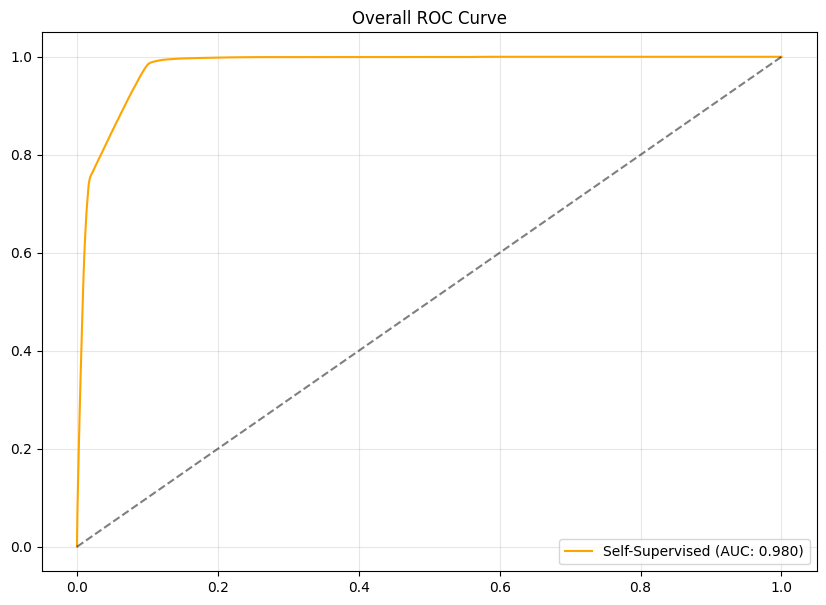

In [24]:
# fig, axes = plt.subplots(1, 2, figsize=(18, 7))
plt.figure(figsize=(10, 7))

# Plot A: ROC Curves (Overall)
# fpr_sup, tpr_sup, _ = roc_curve(y_true, y_sup)
fpr_unsup, tpr_unsup, _ = roc_curve(test_labels, test_probs)

# axes[0].plot(fpr_sup, tpr_sup, label=f'Supervised (AUC: {auc_sup_all:.3f})', color='blue')
plt.plot(fpr_unsup, tpr_unsup, label=f'Self-Supervised (AUC: {test_auc:.3f})', color='orange')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.title('Overall ROC Curve')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

---

## 4. Experiment 2 — Supervised Edge Classification

This section implements the **primary model**. It is explicitly trained to classify each edge as *Laundering* or *Normal*.

### 4.1. Model Architecture — `LaundroGraphSupervised`

The encoder is **identical** to Section 3.1. Key differences:

| Component | Self-Supervised | Supervised |
|---|---|---|
| **Decoder input** | Hadamard ($z_c \odot z_t \in \mathbb{R}^{64}$) | Concatenation ($z_c \| z_t \in \mathbb{R}^{128}$) |
| **Decoder MLP** | 64 → 32 → 1 | 128 → 64 → 1 |
| **Regularization** | None | Dropout(0.2) |
| **Normalization** | Residual only | Residual + LayerNorm |
| **Loss** | BCE (real vs. fake edges) | **Weighted BCE** ($w \approx 939.8$) |
| **Neg. sampling** | 1:1 ratio | Disabled |

In [13]:
class LaundroGraphSupervised(torch.nn.Module):
    def __init__(self, hidden_channels, out_channels, metadata, num_heads=2):
        super().__init__()
        self.num_heads = num_heads
        edge_types = metadata[1]

        # --- 1. ENCODER (Same as before) ---
        self.cust_lin = Linear(-1, hidden_channels)
        self.tx_lin   = Linear(-1, hidden_channels)

        conv1_dict = {
            edge_type: GATConv(hidden_channels, hidden_channels, heads=num_heads, add_self_loops=False)
            for edge_type in edge_types
        }
        self.encoder1 = HeteroConv(conv1_dict, aggr='sum')

        conv2_dict = {
            edge_type: GATConv(hidden_channels * num_heads, out_channels, heads=num_heads, add_self_loops=False, concat=False)
            for edge_type in edge_types
        }
        self.encoder2 = HeteroConv(conv2_dict, aggr='sum')

        self.norm_cust = LayerNorm(out_channels)
        self.norm_tx   = LayerNorm(out_channels)

        # --- 2. DECODER (CHANGED for Classification) ---
        # Input: Concatenation of Customer (64) + Transaction (64) = 128
        self.decoder = torch.nn.Sequential(
            torch.nn.Linear(out_channels * 2, out_channels), # 128 -> 64
            torch.nn.ReLU(),
            torch.nn.Dropout(0.2),  # Added Dropout to prevent overfitting
            torch.nn.Linear(out_channels, 1)                 # 64 -> 1 (Logit)
        )

    def forward_encoder(self, x_dict, edge_index_dict):
        # Same Logic: Project -> GNN -> Residual Connection -> Norm
        x_cust_proj = F.relu(self.cust_lin(x_dict['customer']))
        x_tx_proj   = F.relu(self.tx_lin(x_dict['transaction']))
        x_dict_proj = {'customer': x_cust_proj, 'transaction': x_tx_proj}

        x_gnn1 = self.encoder1(x_dict_proj, edge_index_dict)
        x_gnn1 = {key: F.relu(x) for key, x in x_gnn1.items()}
        x_gnn2 = self.encoder2(x_gnn1, edge_index_dict)

        z_cust = self.norm_cust(x_gnn2['customer'] + x_cust_proj)
        z_tx   = self.norm_tx(x_gnn2['transaction'] + x_tx_proj)

        return {'customer': z_cust, 'transaction': z_tx}

    def forward_decoder(self, z_c, z_t, edge_label_index):
        # 1. Fetch Embeddings
        z_c_batch = z_c[edge_label_index[0]]
        z_t_batch = z_t[edge_label_index[1]]

        # 2. CONCATENATE (The "Feature Engineering" Step)
        # We put them side-by-side so the MLP can mix their features
        combined = torch.cat([z_c_batch, z_t_batch], dim=1)

        # 3. Classify
        return self.decoder(combined).view(-1)

### 4.2. Training Loop — Supervised Edge Classification

Key differences from self-supervised training:
1. **Real labels** — ground-truth `Is_laundering` per edge; no negative sampling.
2. **Weighted BCE** — $w_{\text{pos}} = N_{\text{neg}} / N_{\text{pos}} \approx 939.8$

| Hyperparameter | Value |
|---|---|
| Batch Size | 1024 |
| Positive Class Weight | ~939.8 |
| Epochs | 5 |
| Loss | Weighted BCEWithLogitsLoss |

In [14]:
def train_supervised_edge_class(global_data, full_df, epochs=5, batch_size=1024, checkpoint_path='best_supervised_laundrograph.pt'):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Training Supervised Classifier on: {device}")

    # --- 1. PREPARE LABELS & WEIGHTS ---
    # We map the dataframe labels to the graph edges
    # Important: Ensure full_df matches the order of edges in global_data
    all_labels = torch.tensor(full_df['Is_laundering'].values, dtype=torch.float)
    global_data['customer', 'sends', 'transaction'].y = all_labels

    # Calculate Class Weight (Critical for 0.1% imbalance)
    # We check only the Training portion to avoid data leakage in weighting
    train_labels = all_labels[global_data.sup_mask_ids]
    num_pos = train_labels.sum().item()
    num_neg = len(train_labels) - num_pos

    # Weight = Negatives / Positives (e.g., 999/1 = 999)
    # This tells the loss function: "Paying attention to 1 laundering case is worth 999 normal ones"
    pos_weight = torch.tensor([num_neg / max(num_pos, 1)]).to(device)
    print(f"  Positives: {int(num_pos)} | Negatives: {int(num_neg)}")
    print(f"  Using Positive Class Weight: {pos_weight.item():.2f}")

    # --- 2. SETUP LOADERS ---
    # We use LinkNeighborLoader but disable negative sampling

    # Training Loader
    train_loader = LinkNeighborLoader(
        global_data,
        num_neighbors=[20, 10],
        edge_label_index=(('customer', 'sends', 'transaction'),
                          global_data['customer', 'sends', 'transaction'].edge_index[:, global_data.sup_mask_ids]),
        edge_label=global_data['customer', 'sends', 'transaction'].y[global_data.sup_mask_ids], # Real Labels!
        neg_sampling_ratio=0.0,  # Disable Fake Edges
        batch_size=batch_size,
        shuffle=True,
        num_workers=2
    )

    # Validation Loader
    val_loader = LinkNeighborLoader(
        global_data,
        num_neighbors=[20, 10],
        edge_label_index=(('customer', 'sends', 'transaction'),
                          global_data['customer', 'sends', 'transaction'].edge_index[:, global_data.val_mask_ids]),
        edge_label=global_data['customer', 'sends', 'transaction'].y[global_data.val_mask_ids],
        neg_sampling_ratio=0.0,
        batch_size=batch_size,
        shuffle=False
    )

    # --- 3. MODEL & OPTIMIZER ---
    model = LaundroGraphSupervised(64, 64, global_data.metadata()).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    # We pass the calculated weight to the loss function
    criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    best_val_auc = 0

    # --- 4. LOOP ---
    for epoch in range(epochs):
        model.train()
        total_loss = 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}", leave=False)
        for batch in pbar:
            batch = batch.to(device)
            optimizer.zero_grad()

            # Forward
            z_dict = model.forward_encoder(batch.x_dict, batch.edge_index_dict)

            # Decode (Using Concatenation)
            edge_label_index = batch['customer', 'sends', 'transaction'].edge_label_index
            logits = model.forward_decoder(z_dict['customer'], z_dict['transaction'], edge_label_index)

            # Loss
            target = batch['customer', 'sends', 'transaction'].edge_label.float()
            loss = criterion(logits, target)

            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        # Validation
        model.eval()
        val_preds = []
        val_targets = []

        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                z_dict = model.forward_encoder(batch.x_dict, batch.edge_index_dict)
                edge_label_index = batch['customer', 'sends', 'transaction'].edge_label_index
                logits = model.forward_decoder(z_dict['customer'], z_dict['transaction'], edge_label_index)

                val_preds.append(torch.sigmoid(logits).cpu())
                val_targets.append(batch['customer', 'sends', 'transaction'].edge_label.cpu())

        all_preds = torch.cat(val_preds).numpy()
        all_targets = torch.cat(val_targets).numpy()

        try:
            val_auc = roc_auc_score(all_targets, all_preds)
            val_ap = average_precision_score(all_targets, all_preds)
        except:
            val_auc = 0.5 # Handle case if batch has only 1 class
            val_ap = 0.0

        print(f"Epoch {epoch+1}: Loss {total_loss/len(train_loader):.4f} | Val AUC: {val_auc:.4f} | Val AP: {val_ap:.4f}")

        if val_auc > best_val_auc:
            best_val_auc = val_auc
            torch.save(model.state_dict(), checkpoint_path)

    return model

### 4.3. Execute Supervised Training

Prepare full DataFrame (train+test) and launch supervised training.

In [27]:
# 1. Combine DataFrames (Ensure strictly correct order!)
# If global_data was built from train + val + test, recreate that order:
full_df = pd.concat([train_df, test_df], ignore_index=True)

# 2. Run Training
supervised_model = train_supervised_edge_class(global_data, full_df, epochs=5,
                                               checkpoint_path='best_supervised_laundrograph_02_05_26.pt') #'best_supervised_laundrograph.pt'

Training Supervised Classifier on: cuda
  Positives: 1444 | Negatives: 1357114
  Using Positive Class Weight: 939.83


/usr/local/lib/python3.12/dist-packages/torch_geometric/loader/link_neighbor_loader.py:252: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(


Epoch 1: Loss 0.7023 | Val AUC: 0.9553 | Val AP: 0.0317


Epoch 2: Loss 0.4942 | Val AUC: 0.9629 | Val AP: 0.0434


Epoch 3: Loss 0.4127 | Val AUC: 0.9654 | Val AP: 0.0665


Epoch 4: Loss 0.3753 | Val AUC: 0.9713 | Val AP: 0.0875


Epoch 5: Loss 0.3579 | Val AUC: 0.9691 | Val AP: 0.0907


### 4.4. Load Pre-trained Supervised Checkpoint

Reload the best supervised model checkpoint.

In [15]:
# 1. Initialize Model Architecture (Must match training config)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
supervised_model = LaundroGraphSupervised(hidden_channels=64, out_channels=64, metadata=global_data.metadata()).to(device)

# 2. Load the Weights
checkpoint_path='best_supervised_laundrograph_02_05_26.pt'
if os.path.exists(checkpoint_path):
    print(f"Loading model from {checkpoint_path}...")
    supervised_model.load_state_dict(torch.load(checkpoint_path, map_location=device))
else:
    print("Warning: Checkpoint not found. Using untrained model.")

Loading model from best_supervised_laundrograph_02_05_26.pt...


### 4.5. Inference — Supervised Prediction Pipeline

1. Generate embeddings for all nodes via `NeighborLoader`
2. Score test edges: $P(\text{launder} \mid c, t) = \sigma(\text{MLP}(z_c \| z_t))$
3. Return per-edge probabilities and test transaction embeddings

In [16]:
@torch.no_grad()
def predict_supervised_optimized(model, global_data):
    """
    Generates predictions and transaction embeddings for the SUPERVISED model.
    Optimization: computes embeddings in chunks to save GPU RAM.
    """
    print("\n--- Starting Optimized Supervised Prediction ---")
    model.eval()
    device = next(model.parameters()).device

    # --- HELPER: Generic Embedding Generator ---
    def get_embeddings_for_type(target_type):
        print(f"\nStep: Generating embeddings for '{target_type}'...")
        loader = NeighborLoader(
            global_data,
            num_neighbors=[20, 10],
            input_nodes=target_type, # Calculate for ALL nodes of this type
            batch_size=4096,         # Large batch size for speed
            shuffle=False,
            num_workers=2
        )

        embeddings = []
        for batch in tqdm(loader, desc=f"  {target_type} Batches"):
            batch = batch.to(device)
            # Encode
            out = model.forward_encoder(batch.x_dict, batch.edge_index_dict)
            # Save only the target nodes to CPU
            batch_size = batch[target_type].batch_size
            embeddings.append(out[target_type][:batch_size].cpu())
            del batch, out

        return torch.cat(embeddings, dim=0)

    # 1. CALCULATE ALL EMBEDDINGS (Full Context)
    # We need ALL customers and ALL transactions to handle the indexing correctly
    z_cust_all = get_embeddings_for_type('customer')
    z_tx_all   = get_embeddings_for_type('transaction')

    gc.collect() # Free up RAM

    # 2. SCORE TEST EDGES ONLY
    print("\nStep: Scoring Test Transactions...")

    # Get Test Edges
    test_mask = global_data.test_mask_ids
    test_edge_index = global_data['customer', 'sends', 'transaction'].edge_index[:, test_mask]
    num_test = test_edge_index.size(1)

    scores_list = []

    # Process scoring in chunks (CPU is fast enough for this linear layer)
    batch_size = 50000
    model.cpu() # Move entire model to CPU for the decoding part (saves GPU memory)

    for i in tqdm(range(0, num_test, batch_size), desc="  Scoring Batches"):
        # Slice edges
        batch_edges = test_edge_index[:, i : i + batch_size]

        # Look up embeddings (Fast indexing)
        c_emb = z_cust_all[batch_edges[0]]
        t_emb = z_tx_all[batch_edges[1]]

        # Decode
        with torch.no_grad():
            # SUPERVISED DECODER LOGIC: Concatenation!
            # (Your previous model used .cat, so we must match that)
            # Note: We use forward_decoder if available, or manually replicate it
            # To be safe, let's manually call the decoder layer
            combined = torch.cat([c_emb, t_emb], dim=1)
            logits = model.decoder(combined).view(-1)
            probs = torch.sigmoid(logits)

        scores_list.append(probs)

    final_probs = torch.cat(scores_list)

    # 3. PREPARE RETURN VALUES
    # We return the probabilities AND the specific embeddings for test transactions
    # (This makes plotting easier later)

    # Get the indices of transactions that are in the test set
    # The second row of test_edge_index contains the Transaction IDs
    test_tx_ids = test_edge_index[1]
    z_tx_test = z_tx_all[test_tx_ids]

    print(f"Done. Generated {len(final_probs)} predictions.")
    return final_probs, z_tx_test

### 4.6. Execute Supervised Prediction on Test Set

In [17]:
# --- EXECUTE ---
sup_probs, sup_z_tx = predict_supervised_optimized(supervised_model, global_data)


--- Starting Optimized Supervised Prediction ---

Step: Generating embeddings for 'customer'...


/usr/local/lib/python3.12/dist-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(
  customer Batches: 100%|██████████| 158/158 [00:13<00:00, 12.08it/s]



Step: Generating embeddings for 'transaction'...


  transaction Batches: 100%|██████████| 1266/1266 [01:56<00:00, 10.88it/s]



Step: Scoring Test Transactions...


  Scoring Batches: 100%|██████████| 14/14 [00:00<00:00, 32.39it/s]


Done. Generated 656582 predictions.


### 4.7. Save Supervised Artifacts

Persist probabilities and embeddings for the analysis notebook.

In [18]:
torch.save(sup_probs, 'sup_probs_02_05_26.pt') # 'sup_probs.pt'
torch.save(sup_z_tx, 'sup_z_tx_02_05_26.pt')

---

## 5. Evaluation — Supervised Edge Classification Metrics

Evaluate the supervised model on the held-out test set:
- **ROC AUC** — threshold-independent discriminative power
- **MCC** — balanced metric for imbalanced classification
- **Confusion Matrix** — visual breakdown of predictions

### 5.1. Prepare Predictions

Convert supervised probabilities from PyTorch tensor to NumPy array.

In [19]:
sup_probs = sup_probs.numpy()

### 5.2. Confusion Matrix Visualization

Plot confusion matrix with raw counts and row-normalized percentages at the default 0.5 threshold.

In [20]:
def plot_comprehensive_confusion_matrix(y_true, y_pred_probs, threshold=0.5, labels=['Normal', 'Laundering']):
    """
    Plots a comprehensive confusion matrix with both raw counts and percentages.
    """
    # Convert probabilities to binary predictions
    y_pred = (y_pred_probs >= threshold).astype(int)

    cm = confusion_matrix(y_true, y_pred)
    cm_norm = confusion_matrix(y_true, y_pred, normalize='true')

    fig, ax = plt.subplots(figsize=(8, 6))

    # Use seaborn for a cleaner heatmap
    sns.heatmap(cm_norm, annot=False, cmap='Blues', fmt='.2f', ax=ax,
                xticklabels=labels, yticklabels=labels)

    # Manually add text annotations for both count and percentage
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            text_color = "white" if cm_norm[i, j] > 0.5 else "black"
            ax.text(j + 0.5, i + 0.5, f"{cm[i, j]}\n({cm_norm[i, j]*100:.1f}%)",
                    ha="center", va="center", color=text_color, fontweight='bold')

    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.title(f'Confusion Matrix (Threshold: {threshold})')
    plt.show()

### 5.3. Execute Confusion Matrix on Test Set

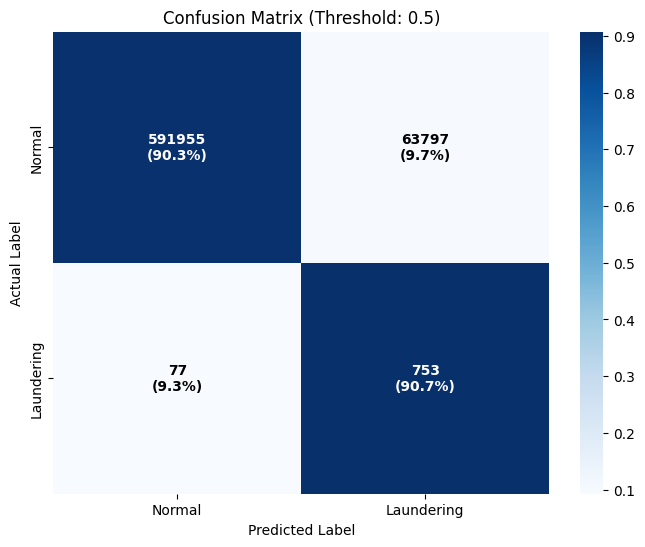

In [25]:
# Execute the comprehensive confusion matrix on the test set
y_true = test_df['Is_laundering'].values

# Using a standard 0.5 threshold first
plot_comprehensive_confusion_matrix(y_true, sup_probs, threshold=0.5)

### 5.4. ROC AUC & MCC Scores

The supervised model achieves a **0.969 ROC AUC** on the test set.

In [26]:
print('ROC_AUC_SCORE on TEST is:', roc_auc_score(test_df['Is_laundering'], sup_probs))
print('MCC on TEST is:', matthews_corrcoef(test_df['Is_laundering'], (sup_probs >= 0.5).astype(int)))

ROC_AUC_SCORE on TEST is: 0.9633021343508206
MCC on TEST is: 0.09665878231848633


### 5.5. Optimal Classification Threshold Search

Sweep 100 thresholds in $[0, 1]$ and select the one maximizing **MCC**.

In [27]:
# Assuming 'all_targets' are your true labels (0 or 1)
# and 'all_preds' are your model's predicted probabilities (0.0 to 1.0)

all_preds = sup_probs
all_targets = test_df['Is_laundering'].values

best_mcc = -1
best_threshold = 0.5

# Test 100 different thresholds between 0 and 1
thresholds = np.linspace(0, 1, 100)

for t in thresholds:
    # Convert probabilities to hard classes using the current threshold
    hard_preds = (all_preds >= t).astype(int)

    # Calculate MCC
    mcc = matthews_corrcoef(all_targets, hard_preds)

    if mcc > best_mcc:
        best_mcc = mcc
        best_threshold = t

print(f"Optimal Threshold: {best_threshold:.4f}")
print(f"Max MCC achieved: {best_mcc:.4f}")

Optimal Threshold: 0.9899
Max MCC achieved: 0.2612


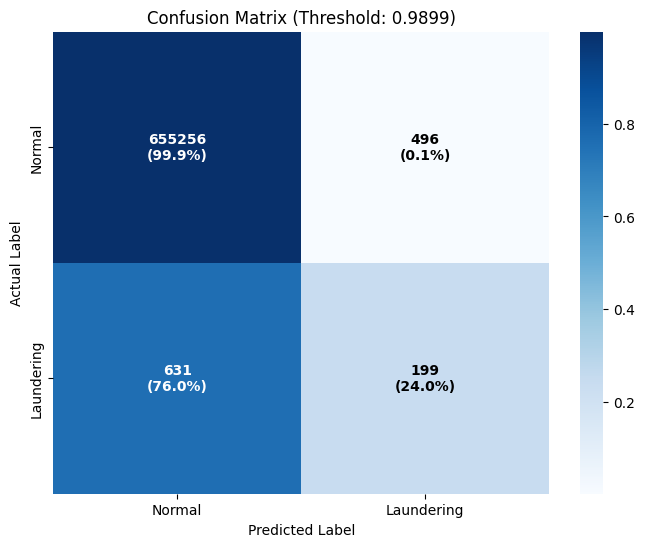

In [28]:
# Using a standard 0.9899 threshold first
plot_comprehensive_confusion_matrix(y_true, sup_probs, threshold=0.9899)